<a href="https://colab.research.google.com/github/stakewant/bigdatacomputing/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  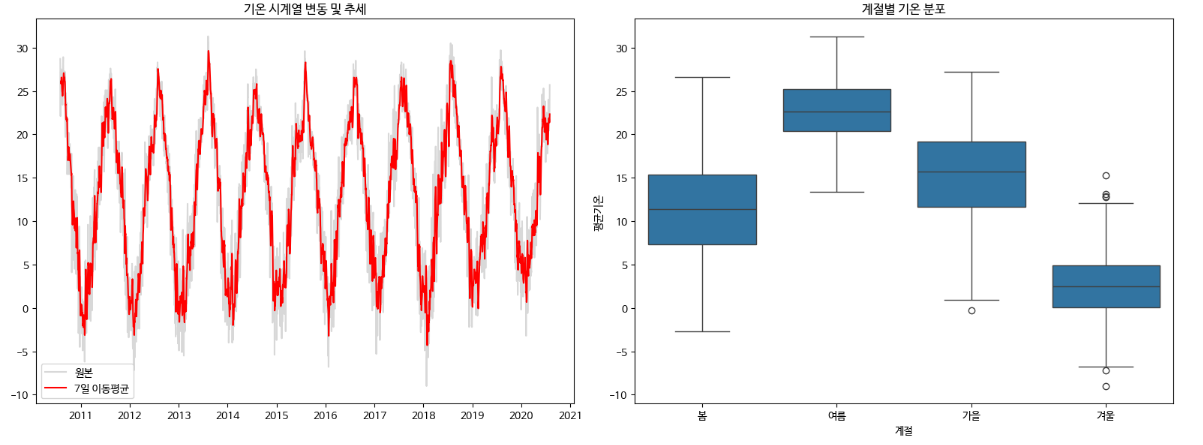

  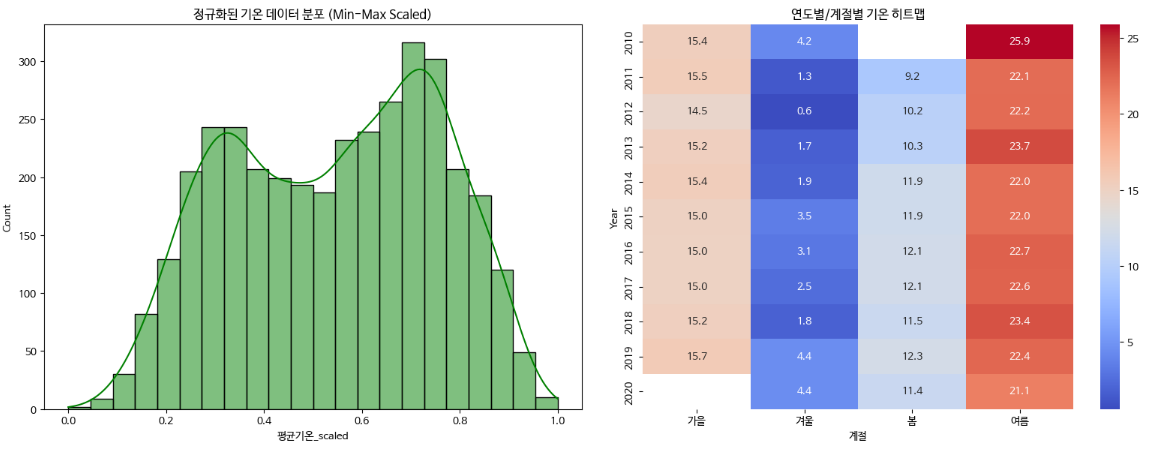



In [2]:
def setup_environment():
    warnings.filterwarnings('ignore')

    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'


    if not os.path.exists(font_path):
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 완료")

In [3]:
def load_data(file_path):
    df = pd.read_csv(file_path, encoding='cp949')
    print("✅ 데이터 로드 완료")
    return df

In [4]:
def preprocess_data(df):
  # 날짜 데이터 변환
  df['일시'] = pd.to_datetime(df['일시'])

  # 날짜 기준 정렬
  df = df.sort_values('일시')

  df = df.set_index('일시', drop=False)

  # 결측치 처리
  df['평균기온'] = df['평균기온'].interpolate()
  df['최대풍속'] = df['최대풍속'].fillna(df['최대풍속'].mean())
  df['평균풍속'] = df['평균풍속'].fillna(df['평균풍속'].mean())

  # 날짜 관련 정보 추출
  dt_index= pd.DatetimeIndex(df['일시'])
  df['연도'] = dt_index.year
  df['월'] = dt_index.month

  # 월 정보를 기준으로 계절 분류
  df['계절'] = np.where(df['월'].isin([3, 4, 5]), '봄',
               np.where(df['월'].isin([6, 7, 8]), '여름',
               np.where(df['월'].isin([9, 10, 11]), '가을', '겨울')))

  return df

In [5]:
def min_max_scale(series):
    result = (series - series.min()) / (series.max() - series.min())
    return result

In [6]:
def add_scaled_columns(df):
  df['평균기온_정규화'] = min_max_scale(df['평균기온'])
  df['최대풍속_정규화'] = min_max_scale(df['최대풍속'])
  df['평균풍속_정규화'] = min_max_scale(df['평균풍속'])

  return df

In [7]:
def calculate_moving_average(df):
  moving_avg = []

  for i in range(len(df)):
    if i < 6:
      moving_avg.append(np.nan)
    else:
      avg = df['평균기온'].iloc[i-6:i+1].mean()
      moving_avg.append(avg)

  df['7일이동평균'] = moving_avg

  return df

In [8]:
def make_concat_df(df):
  temp_df = df[['일시', '평균기온', '평균기온_정규화', '7일이동평균']]
  wind_df = df[['최대풍속', '평균풍속', '최대풍속_정규화', '평균풍속_정규화']]

  concat_df = pd.concat([temp_df, wind_df], axis=1)

  return concat_df

In [9]:
def make_monthly_mean(df):
  monthly_mean_df = df.groupby(['연도', '월'])[['평균기온', '최대풍속', '평균풍속']].mean().reset_index()
  monthly_mean_df.columns = ['연도', '월', '월평균기온', '월평균최대풍속', '월평균평균풍속']

  return monthly_mean_df

In [10]:
def make_season_mean(df):
  season_mean_df = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean().reset_index()
  season_mean_df.columns = ['계절', '계절평균기온', '계절평균최대풍속', '계절평균평균풍속']

  return season_mean_df

In [11]:
def make_pivot_table(df):
  pivot_df = df.pivot_table(
      index = '연도',
      columns = '월',
      values = '평균기온',
      aggfunc = 'mean'
  )

  pivot_df = pivot_df.round(2)

  return pivot_df

In [12]:
def make_heatmap_data(df):
  season_order = ['가을', '겨울', '봄', '여름']

  heatmap_df = df.pivot_table(
      index = '연도',
      columns = '계절',
      values = '평균기온',
      aggfunc = 'mean'
  )

  heatmap_df = heatmap_df[season_order]
  heatmap_df = heatmap_df.round(1)

  return heatmap_df

In [13]:
def draw_temperature_graph(df, heatmap_df):
 plt.figure(figsize=(14, 10))

 # 1. 기온 시계열 변동 및 추세
 plt.subplot(2, 2, 1)
 plt.plot(df['일시'], df['평균기온'], color='lightgray', label='원본')
 plt.plot(df['일시'], df['7일이동평균'], color='red', label='7일이동평균')
 plt.title('기온 시계열 변동 및 추세')
 plt.xlabel('일시')
 plt.ylabel('평균기온')
 plt.legend(loc="lower left")
 plt.grid()

 # 2. 계절별 기온 분포
 plt.subplot(2, 2, 2)

 sns.boxplot(
     data=df,
     x='계절',
     y='평균기온',
     order=['봄', '여름', '가을', '겨울'],
     color='steelblue'
 )

 plt.title('계절별 기온 분포')
 plt.xlabel('계절')
 plt.ylabel('평균기온')
 plt.grid()

 # 3. 정규화된 기온 데이터 분포
 plt.subplot(2, 2, 3)

 sns.histplot(
     data=df,
     x='평균기온_정규화',
     bins=30,
     kde=True,
     color='green',
     edgecolor='black'
 )

 plt.title('정규화된 기온 데이터 분포 (Min-Max Scaled)')
 plt.xlabel('평균기온_scaled')
 plt.ylabel('Count')
 plt.grid()

 # 4. 연도/계절별 기온 히트맵
 plt.subplot(2, 2, 4)
 image = plt.imshow(heatmap_df, cmap='coolwarm', aspect='auto')

 plt.title('연도/계절별 기온 히트맵')
 plt.xlabel('계절')
 plt.ylabel('Year')

 plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns)
 plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)

 for i in range(len(heatmap_df.index)):
  for j in range(len(heatmap_df.columns)):
    value = heatmap_df.iloc[i, j]
    plt.text(j, i, value, ha='center', va='center', color='black', fontsize=8)

 plt.colorbar(image)

 plt.tight_layout()
 plt.show()

In [14]:
def draw_season_graph(season_mean_df):
  plt.figure(figsize=(8, 5))

  plt.bar(season_mean_df['계절'], season_mean_df['계절평균기온'])

  plt.title('계절별 평균기온')
  plt.xlabel('계절')
  plt.ylabel('평균기온')
  plt.grid()

  plt.show()

In [15]:
def save_to_excel(df, concat_df, monthly_mean_df, season_mean_df, pivot_df):
  file_name = 'weather_analysis_report.xlsx'

  with pd.ExcelWriter(file_name) as writer:
    df.to_excel(writer, sheet_name='전처리데이터', index=False)
    season_mean_df.to_excel(writer, sheet_name='계절별통계', index=False)
    pivot_df.to_excel(writer, sheet_name='연도별피벗테이블')

  print(file_name)

✅ 환경 설정 완료
✅ 데이터 로드 완료


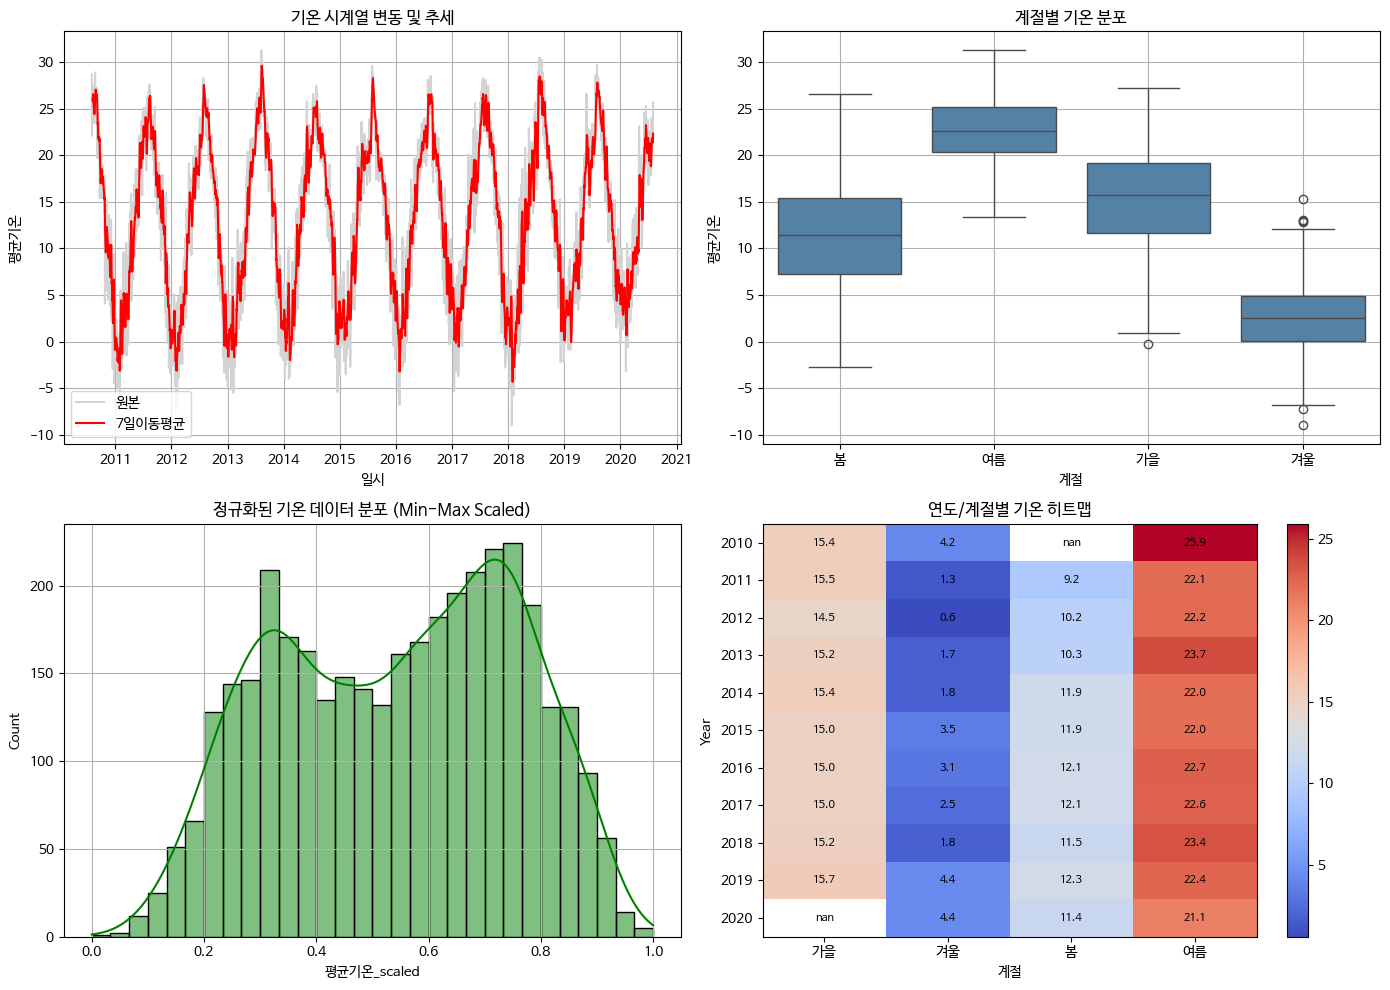

weather_analysis_report.xlsx


In [16]:
def main():
  setup_environment()

  file_path = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

  df = load_data(file_path)

  df = preprocess_data(df)

  df = add_scaled_columns(df)

  df = calculate_moving_average(df)

  concat_df = make_concat_df(df)

  monthly_mean_df = make_monthly_mean(df)

  season_mean_df = make_season_mean(df)

  pivot_df = make_pivot_table(df)

  heatmap_df = make_heatmap_data(df)

  draw_temperature_graph(df, heatmap_df)

  save_to_excel(df, concat_df, monthly_mean_df, season_mean_df, pivot_df)

if __name__ == "__main__":
  main()